##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells.

# EXAM03: Data Science Group Assignment - Iteration 3

**Group name:** Rabbitions

**Student names & numbers:**
* [Sanne Jimkes] - [000101379]
* [Naimi de Jong] - [000100775]


---

## 0. Iteration setup

**Import libraries**

In [1]:
# CODE CELL: Import the necessary libraries for this iteration (including scikit-learn models and metrics)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

**Load & Merge dataset(s)**

In [2]:
# CODE CELL: Import the necessary datasets for this iteration.
# Load your fully cleaned dataset from Iteration 2 AND the new performance logs.
# Merge them together based on the Ship_ID

df_inv = pd.read_csv("../data/clean_it2_inventory.csv")
df_perf = pd.read_csv("../data/ship_performance_logs_iter3.csv")
# Merge the inventory and performance datasets on Ship_ID
df = pd.merge(df_inv, df_perf, on="Ship_ID", how="left")

---

## 1. Business Understanding

**Situation description**

*Describe the final problem. Why is Nebula Brokerage moving from the simple models (iterations 1 and 2) to a machine learning approach?*

* The previous models were too simplistic: Iteration 1 used simple pricing benchmarks that underpriced high-performance ships and overpriced worn-out ones. Iteration 2 used manual rules to classify ship condition but missed hidden risks, like ships with illegal or stolen registration. Nebula Brokerage needs more precise, scalable, and data-driven predictions to maximize revenue and ensure safety compliance. Machine learning allows the company to automatically learn patterns from new odometer and legal data, improving both pricing and safety decisions.

**Business objective(s)**

*Justify why an AI-driven pipeline (predicting both Galactic Credits and Condition) adds business value.*

* An AI-driven pipeline improves pricing accuracy by incorporating ship usage (Lightyears_Traveled), reducing revenue loss from underpricing or overpricing. It also improves safety and compliance by including legal information (Registration_Status), helping to identify risky ships before sale. Together, this reduces financial and legal risks while increasing shareholder value.

**Data mining goal(s)**

*Explain the two modeling tasks for this iteration.*

* Price optimization: a regression task to predict Galactic_Credits using numeric features including Lightyears_Traveled, Model_Cycle, Reactor_Power, etc.
* Safety compliance: a classification task to predict Hull_Integrity using categorical and numeric features including Registration_Status, Propulsion_Type, and Ship_Class.

**Success criteria**

*Determine the success criteria.*

* Price model: lower MAE and RMSE than the Iteration 1 benchmark, especially for high-usage or high-value ships.
* Safety model: higher accuracy and better detection of Critical ships than the Iteration 2 manual rules (baseline ~68% overall accuracy), with minimal dangerous misclassifications.
* Both models must produce actionable insights that reduce financial and safety risks, showing measurable business value.

---

## 2. Data Understanding

**Data exploration (New Features)**

*Show the summary statistics for the newly merged data. Focus your description on the new variables: Lightyears_Traveled and Registration_Status.*

In [3]:
# CODE CELL: Show basic statistics and information for the final merged dataset
# Summary statistics for numerical column
print(df['Lightyears_Traveled'].describe())
print("\n")

# Value counts for categorical column
print(df['Registration_Status'].value_counts())
print("\n")

# Percentage distribution
print(df['Registration_Status'].value_counts(normalize=True) * 100)
print("\n")

# Correlation with price
print("Correlation with Galactic_Credits:", df['Lightyears_Traveled'].corr(df['Galactic_Credits']))

count    361069.000000
mean        104.826990
std          88.943005
min           0.000000
25%          30.606552
50%          85.477075
75%         157.545516
max        1559.606111
Name: Lightyears_Traveled, dtype: float64


Registration_Status
Imperial Certified    175316
Refurbished            75884
Smuggler Logic         44117
Stolen                 29443
Scrap                  29391
Unknown                 6918
Name: count, dtype: int64


Registration_Status
Imperial Certified    48.554708
Refurbished           21.016482
Smuggler Logic        12.218440
Stolen                 8.154397
Scrap                  8.139995
Unknown                1.915977
Name: proportion, dtype: float64


Correlation with Galactic_Credits: -0.6746072723837048


**Lightyears_Traveled**
* Ships have widely varying mileage, from 0 to ~1560 lightyears, with a median of ~85.
Most ships (~50%) have traveled less than 85 lightyears, while 25% have traveled more than 157.
There is a strong negative correlation (-0.67) between Lightyears_Traveled and Galactic_Credits. This means higher mileage generally lowers the ship’s market value, making odometer data critical for price prediction.

**Registration_Status**
* The majority of ships are Imperial Certified (48.6%), followed by Refurbished (21%).
Risky categories exist: Smuggler Logic (12.2%), Stolen (8.15%), and Scrap (8.14%), with a small fraction Unknown (1.9%).
These proportions indicate enough variation to train a classifier, and legal status is likely a strong predictor of Hull_Integrity.

**Implications**
* Lightyears_Traveled is essential for improving price prediction.
Registration_Status provides important legal/safety information that can improve ship condition classification beyond the manual rules from Iteration 2.

**Visualizations and patterns**
*Create visualizations to discover the impact of the new features.*

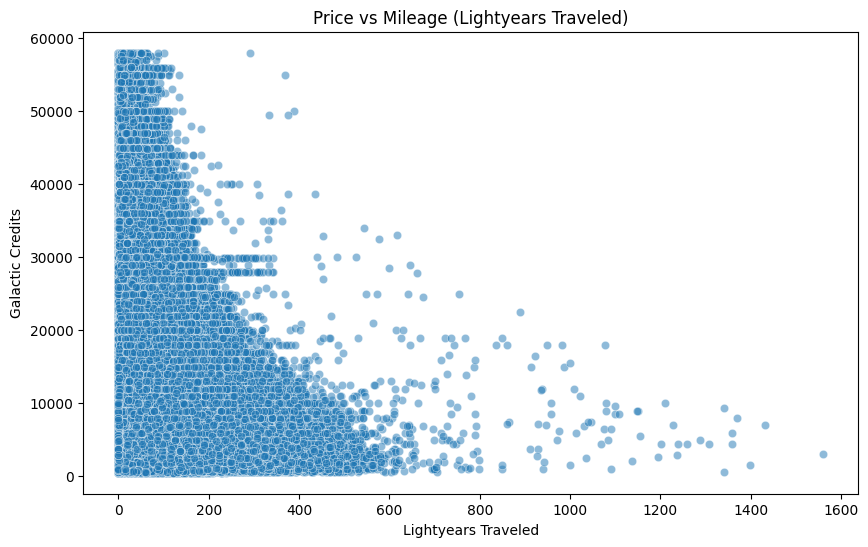

In [4]:
# CODE CELL: Generate visualizations for the new features
# Scatterplot: Lightyears_Traveled vs Galactic_Credits
plt.figure(figsize=(10,6))
sns.scatterplot(x='Lightyears_Traveled', y='Galactic_Credits', data=df, alpha=0.5)
plt.title('Price vs Mileage (Lightyears Traveled)')
plt.xlabel('Lightyears Traveled')
plt.ylabel('Galactic Credits')
plt.show()

**Findings:**
* There is a clear negative relationship: ships that have traveled more lightyears tend to have lower prices.
* Some ships with extremely high mileage are outliers, potentially requiring manual review or special pricing rules.
* Confirms that Lightyears_Traveled is a key feature for predicting fair market price.

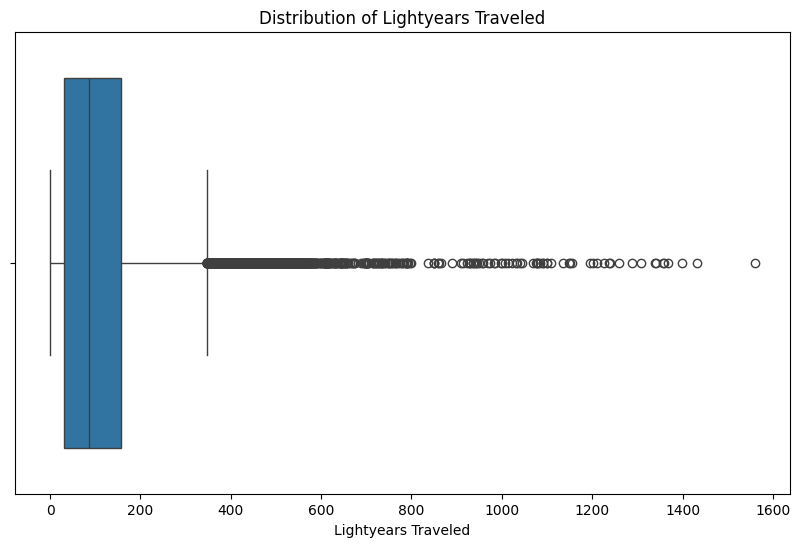

In [5]:
# Boxplot: Lightyears_Traveled distribution
plt.figure(figsize=(10,6))
sns.boxplot(x='Lightyears_Traveled', data=df)
plt.title('Distribution of Lightyears Traveled')
plt.xlabel('Lightyears Traveled')
plt.show()

**Findings:**
* Most ships have less than 200 lightyears traveled, with the median around 85.
* Distribution is right-skewed, meaning a few ships have very high mileage.
* Outliers indicate ships with excessive usage, which should affect their market price predictions.

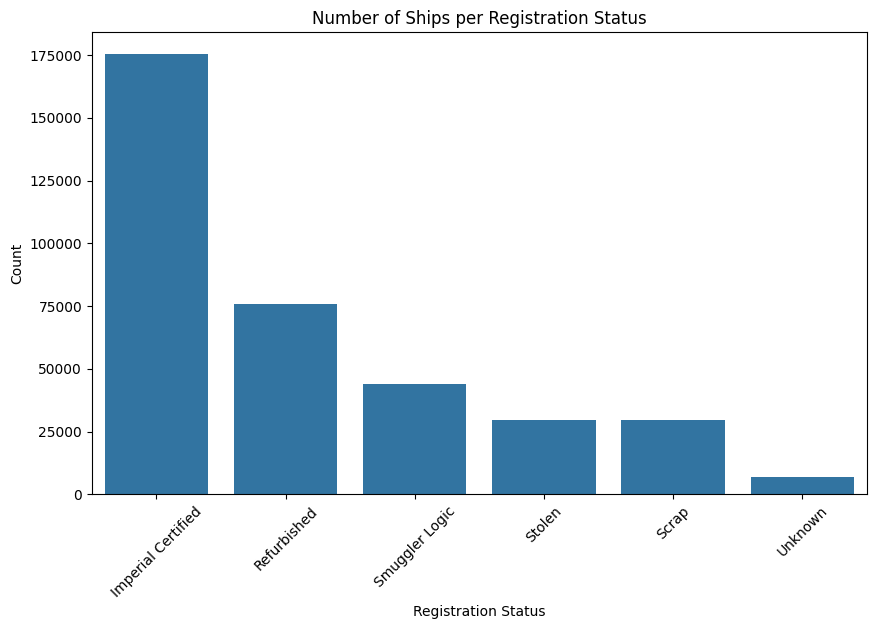

In [6]:
# Bar plot: Registration_Status counts
plt.figure(figsize=(10,6))
sns.countplot(x='Registration_Status', data=df, order=df['Registration_Status'].value_counts().index)
plt.title('Number of Ships per Registration Status')
plt.xlabel('Registration Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

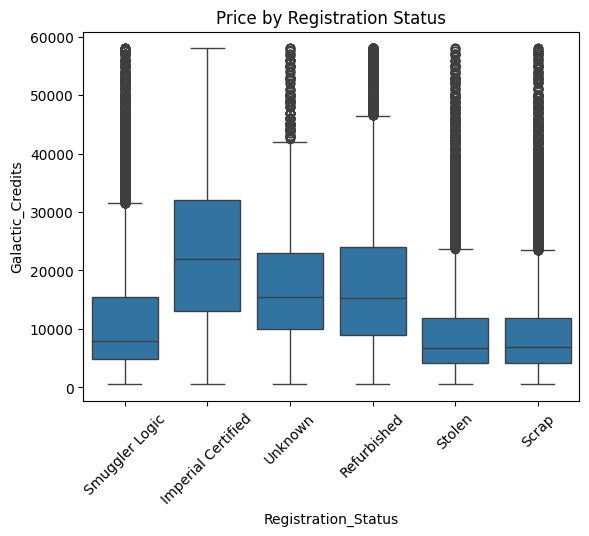

In [7]:
sns.boxplot(x='Registration_Status', y='Galactic_Credits', data=df)
plt.xticks(rotation=45)
plt.title('Price by Registration Status')
plt.show()

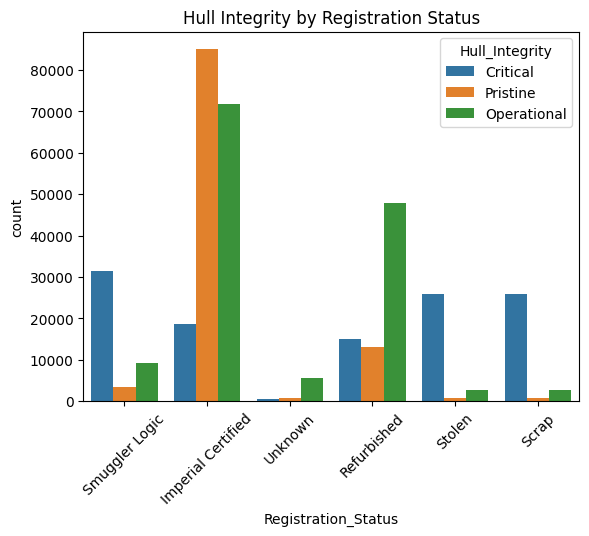

In [8]:
sns.countplot(x='Registration_Status', hue='Hull_Integrity', data=df)
plt.xticks(rotation=45)
plt.title('Hull Integrity by Registration Status')
plt.show()

**Findings:**
* Ships show a wide range of mileage (0 to ~1560), with most ships below 160 lightyears and a median around 85.
* There is a strong negative correlation (-0.67) between Lightyears_Traveled and Galactic_Credits, meaning higher mileage leads to lower prices.
* The majority of ships are Imperial Certified (48.6%), followed by Refurbished (21%).
* Smaller but important categories include Smuggler Logic (12.2%), Stolen (8.15%), and Scrap (8.14%).
* Imperial Certified ships have the highest average prices, while Stolen, Scrap, and Smuggler Logic ships have significantly lower prices.
* Ships with Unknown status have similar price levels to Refurbished ships, which may indicate they are treated as mid-quality ships despite unclear legal status.
* Risky categories (Stolen, Scrap, Smuggler Logic) are strongly associated with Critical hull condition (over 70–87% Critical).
* Imperial Certified ships are mostly Pristine or Operational, indicating better overall condition.
* The data contains some extreme mileage outliers and minor class imbalance, but overall provides useful information for both price prediction and classification.

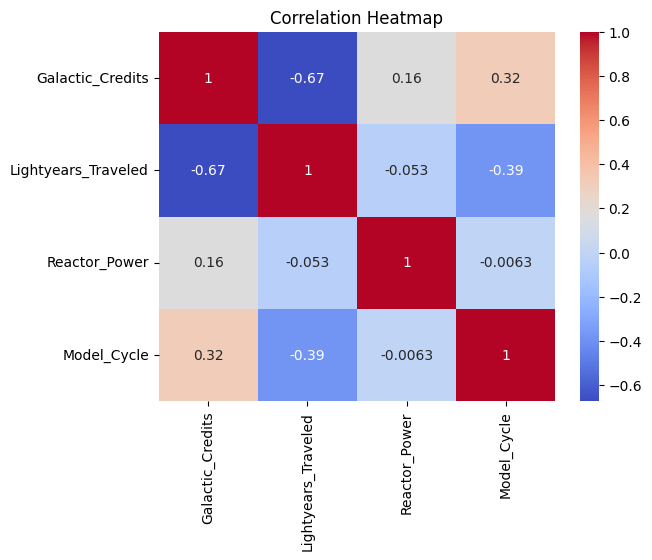

In [9]:
corr = df[['Galactic_Credits','Lightyears_Traveled','Reactor_Power','Model_Cycle']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Findings:**
* There is a strong negative correlation (-0.67) between Galactic_Credits and Lightyears_Traveled, confirming that higher mileage significantly lowers ship prices.
* Model_Cycle shows a moderate positive correlation (0.32) with price, meaning newer ships tend to be more valuable.
* Lightyears_Traveled and Model_Cycle have a moderate negative relationship (-0.39), indicating older ships have typically traveled more.
* Reactor_Power has only a weak positive correlation (0.16) with price, suggesting it has some influence but is not a major driver.
* Reactor_Power shows almost no correlation with Model_Cycle and Lightyears_Traveled, meaning it behaves independently from age and usage.

**Data insights and data quality**

**Insights:**
* There is a strong negative correlation between Lightyears_Traveled and Galactic_Credits (r ≈ -0.675), showing that high mileage generally lowers the ship’s price.
* Ships with Stolen or Scrap registration status have the highest proportion of Critical hulls (~88%), confirming that legal/usage issues are linked to poor condition.
* Imperial Certified ships are mostly Pristine or Operational, indicating that legal clearance is a strong positive indicator of ship quality.
* Unknown and Refurbished ships have similar median mileage and prices, suggesting Unknown may behave similarly to Refurbished in the market.

**Quality issues:**
* Lightyears_Traveled contains missing values (some ships have 0 LY recorded), which will need imputation for regression.
* Registration_Status has a small number of missing entries (~1.9% Unknown), which could be treated as a separate category or imputed.
* Extreme outliers exist in Lightyears_Traveled (up to ~1559 LY) that may affect regression modeling if not addressed.
* Model_Cycle has missing values. The distribution is negatively skewed, so it is better to use the median.

In [10]:
print(df['Lightyears_Traveled'].isna().sum())

7245


In [11]:
# Missing values
df.isnull().sum() 

Ship_ID                        0
Galactic_Credits               0
Model_Cycle                 7398
Ship_Manufacturer              0
Sector                         0
Hull_Integrity                 0
Reactor_Power                  0
Propulsion_Type                0
Ship_Class                     0
Predicted_Hull_Integrity       0
Lightyears_Traveled         7245
Registration_Status         7245
dtype: int64

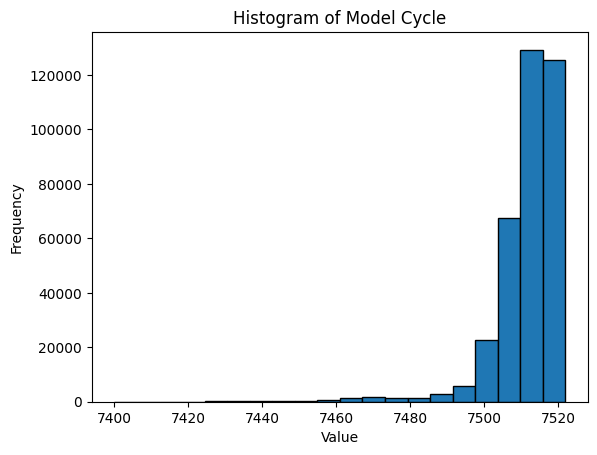

In [12]:
plt.hist(df['Model_Cycle'], bins=20, edgecolor='k')
plt.title("Histogram of Model Cycle")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

---

## 3. Data Preparation

**Cleaning and preprocessing**

In [13]:
# Check missing values
print(df.isnull().sum())

Ship_ID                        0
Galactic_Credits               0
Model_Cycle                 7398
Ship_Manufacturer              0
Sector                         0
Hull_Integrity                 0
Reactor_Power                  0
Propulsion_Type                0
Ship_Class                     0
Predicted_Hull_Integrity       0
Lightyears_Traveled         7245
Registration_Status         7245
dtype: int64


In [ ]:
# 1. Insert the missing values for Lightyears_Traveled with the median
median_ly = df['Lightyears_Traveled'].median()
df['Lightyears_Traveled'] = df['Lightyears_Traveled'].fillna(median_ly)

# 2. Cap outliers at the 99th percentile to stabilize the regression model
cap_value = df['Lightyears_Traveled'].quantile(0.99)
df['Lightyears_Traveled'] = df['Lightyears_Traveled'].clip(upper=cap_value)

**Justification**

1. Handling Missing Values: Since Lightyears_Traveled has around 7,245 missing values, we will use Median Imputation. We use the median rather than the mean because the distribution is right-skewed; the median is less affected by those extreme high-mileage outliers.

2. Outlier Management: For ships with extreme mileage (e.g., >1,500 LY), we will apply Capping (Winsorization). This prevents a few "space junk" outliers from pulling the regression line away from the bulk of the fleet, leading to more stable pricing.

*Model_Cycle*


In [15]:
# 1. Insert the missing value for Model_Cycle with the median
median_mc = df['Model_Cycle'].median()
df['Model_Cycle'] = df['Model_Cycle'].fillna(median_mc)

# Check for any remaining missing values
print(df.isnull().sum())

Ship_ID                        0
Galactic_Credits               0
Model_Cycle                    0
Ship_Manufacturer              0
Sector                         0
Hull_Integrity                 0
Reactor_Power                  0
Propulsion_Type                0
Ship_Class                     0
Predicted_Hull_Integrity       0
Lightyears_Traveled            0
Registration_Status         7245
dtype: int64


**Justification**
 * Handling Missing Values: Model_Cycle contains missing entries. Since its distribution is negatively skewed, we will use median imputation. The median is preferred over the mean because it is less influenced by the lower-end values or extreme early-model cycles, ensuring a more representative replacement for missing data.

**Feature encoding**

*Describe how you converted your categorical columns into a format the model can use.*

In [16]:
# CODE CELL: Apply feature ecoding and define your features (X)
hull_mapping = {
    'Critical': 0,
    'Operational': 1,
    'Pristine': 2
}

df['Hull_Integrity'] = df['Hull_Integrity'].map(hull_mapping)

categorical_cols = ['Registration_Status', 'Ship_Class', 'Ship_Manufacturer']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.head())
print(df.info())

      Ship_ID  Galactic_Credits  Model_Cycle                 Sector  \
0  7316160254              4950       7505.0  Mon Cala Ocean Worlds   
1  7316115206             18999       7518.0       Thraxos Blockade   
2  7315865657              4000       7486.0       Indoumodo Sector   
3  7314772431              6495       7511.0           Pantora Moon   
4  7311539325              3995       7499.0      Malastare Narrows   

   Hull_Integrity  Reactor_Power Propulsion_Type Predicted_Hull_Integrity  \
0               0           40.0       Ion Drive              Operational   
1               2          120.0      Solar Sail                 Pristine   
2               0           40.0       Ion Drive                 Critical   
3               2           40.0   Graviton Beam              Operational   
4               0           40.0      Hyperdrive                 Critical   

   Lightyears_Traveled  Registration_Status_Refurbished  ...  \
0           104.554402                        

First, the variable Hull_Integrity was encoded using ordinal encoding, since it represents an ordered category. The categories were mapped as follows:

Critical → 0
Operational → 1
Pristine → 2

Next, the categorical variables Registration_Status, Ship_Class, and Ship_Manufacturer were transformed using one-hot encoding. This method creates binary columns for each category, allowing machine learning models to process categorical data.

---

## 4. Modeling: Task A

**Regression setup**

*Set up a [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model to predict `Galactic_Credits`. Make sure to split your data into training and testing sets.*

In [17]:
# CODE CELL: Train-Test split & train the Linear Regression model
# Split for the Modeling task A
y_price = df['Galactic_Credits']
X_price = df.drop(['Galactic_Credits', 'Ship_ID'], axis=1)
X_price = X_price.select_dtypes(include=['int64', 'float64'])

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

* We split the dataset into training (80%) and testing (20%) sets to evaluate the model on unseen data, ensuring that performance metrics reflect how it would work in real-world predictions.
* We removed Galactic_Credits because it is the target variable, and Ship_ID because it has no predictive value — including it could bias or overfit the model.
* We selected only numeric (int64, float64) columns because linear regression cannot handle non-numeric categorical data directly. The boolean data isn't relevant for this model

**Train linear regression model**

In [18]:
from sklearn.linear_model import LinearRegression   

model_a = LinearRegression()
model_a.fit(X_train_a, y_train_a)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**Coefficients**

In [19]:
coefficients = pd.DataFrame({
    'Feature': X_price.columns,
    'Coefficient': model_a.coef_
})

# Sort to see most important features
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print(coefficients)

               Feature  Coefficient
1       Hull_Integrity  5781.821516
2        Reactor_Power    58.534943
0          Model_Cycle    -5.917592
3  Lightyears_Traveled   -71.230929


**Findings:**
* Hull_Integrity is the strongest driver of Galactic_Credits, with better hulls increasing price significantly.
* Lightyears_Traveled has a moderate negative impact on price, showing that ships that have traveled more tend to be cheaper.
* Reactor_Power contributes positively but modestly, suggesting that more powerful reactors slightly raise the ship’s value.
* Model_Cycle has a very small negative effect, indicating that newer model cycles slightly reduce price, though the impact is minimal.

**Testing and performance (Regression)**

*Calculate the MAE, RMSE and R2 score. Create a plot showing Actual vs. Predicted prices to visually verify model performance.*

**Predictions**

In [28]:
y_pred_a = model_a.predict(X_test_a)

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# CODE CELL: Evaluate the rgression model and plot Actual vs Predicted
mae = mean_absolute_error(y_test_a, y_pred_a)
mse = mean_squared_error(y_test_a, y_pred_a)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_a, y_pred_a)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 7497.921809825084
MSE: 149219082.78105786
RMSE: 12215.526299798052
R²: 0.38802125780939634


**Plot**


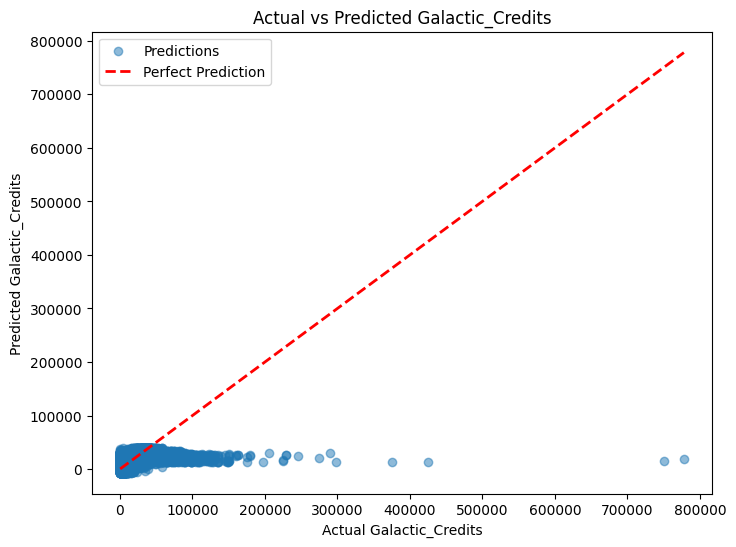

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_a, y_pred_a, alpha=0.5, label='Predictions')
plt.plot([y_test_a.min(), y_test_a.max()],
         [y_test_a.min(), y_test_a.max()],
         'r--', lw=2,
         label='Perfect Prediction')
plt.xlabel("Actual Galactic_Credits")
plt.ylabel("Predicted Galactic_Credits")
plt.title("Actual vs Predicted Galactic_Credits")

plt.legend()
plt.show()

---

## 5. Modeling: Task B

**Classification setup**

*Set up a [Decision Tree Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) to predict `Hull_Integrity`. Split the data into training and testing sets.*

In [21]:
# CODE CELL: Train-Test split & train the Decision Tree model.
# Split for the Modeling task B
# We use 'stratify' to ensure the 'Critical' hulls are represented equally in both sets
y_safety = df['Hull_Integrity']
X_safety = df.drop('Hull_Integrity', axis=1)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_safety, y_safety, test_size=0.2, random_state=42, stratify=y_safety
)

Test train split is used so that we only use 80% of the data to train, and still have 20% data the model is not familiar with to later test.

**Testing and performance (classification)**

*Calculate the Accuracy and plot a confusion matrix. Explain what the matrix tells you about the predictions.*

In [22]:
# CODE CELL: Evaluate your classification model (check ou tthe metrics, include a confusion matrix)

---

## 6. Evaluation

**Assessment against success criteria** 

*Compare your models to the baselines:*
* Model A (comparison to it1)
    * The Linear Regression model outperforms both baseline models (Mean and Median predictors).
        * MAE: 7,498 vs 11,608 (Mean) / 11,283 (Median) → ~35% improvement
        * RMSE: 12,216 vs 15,543 (Mean) / 15,924 (Median) → fewer large errors
    * Reason for improvement: The regression model uses meaningful features such as Hull_Integrity, Lightyears_Traveled, Reactor_Power, which capture real patterns in ship pricing, whereas baseline models ignore these features.

**Key findings**
* Model A
    * The Linear Regression model outperforms both baseline models (Mean and Median predictors).
    * MAE: 7,498 vs 11,608 (Mean) / 11,283 (Median) → ~35% improvement
    * RMSE: 12,216 vs 15,543 (Mean) / 15,924 (Median) → fewer large errors
    * Reason for improvement: The regression model uses meaningful features such as Hull_Integrity, Lightyears_Traveled, Reactor_Power, which capture real patterns in ship pricing, whereas baseline models ignore these features.

**Limitations**
* Model A
    * Moderate R² (~0.39): A large portion of variability in ship prices is unexplained. Other features like Propulsion_Type, Sector, Registration_Status, and non-linear interactions may be important.
    * Outliers and extreme prices still affect predictions, although capping at 30,000 and plotting up to 300,000 mitigates this.
    * Linear Regression assumes a straight-line relationship; complex market effects may require non-linear models.

*What are the final conclusions? Should Nebula Brokerage deploy these models? What are the remaining limitations?*

**Conclusion**
* Model A
    * The newly created Linear Regression model provides value to Nebula Brokerage by identifying key drivers of ship prices. Hull_Integrity strongly increases value, while the newly included Lightyears_Traveled shows that high mileage reduces price, adding actionable insight into market trends. The model explains ~39% of price variance and improves prediction accuracy over naive baselines, though it is not precise enough for exact pricing. Limitations include moderate predictive power, unmodeled categorical variables, non-linear relationships, and the effect of outliers.


Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset.

---

## 7. Personal Contribution

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Sanne Jimkes | 1 Business Understanding, 3 Data Understanding, 4 Modeling model a 5 Evaluation model a | Learned comparing baseline and regression model, interpret coefficients and regression metrics to understand feature impact and model performance|
| Naimi de Jong | 2 Data preparation, 4 Modeling model b, 5 Evaluation model b |Learned how to identify patterns in data to make informed imputations, the value of visualizations in decision-making, and experimenting with predictive approaches for filling missing values.|